In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('0531_data_진짜최종.csv')

FileNotFoundError: [Errno 2] No such file or directory: '0531_data_진짜최종.csv'

In [3]:
df = df.iloc[:11565, :]
df

,Unnamed: 0,Type,Name,Age,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Fee,State,PhotoAmt,AdoptionSpeed,BreedMixed,ColorMixed,Video
0,0,2,Nibble,3,1,1,1,1,2,2,2,1,100,41326,1.0,2.0,False,False,False
1,1,2,No Name Yet,1,1,1,2,2,3,3,3,1,0,41401,2.0,0.0,False,False,False
2,2,1,Brisco,1,1,2,2,2,1,1,2,1,0,41326,7.0,3.0,True,False,False
3,3,1,Miko,4,2,1,2,1,1,1,2,1,150,41401,8.0,2.0,True,False,False
4,4,1,Hunter,1,1,1,2,1,2,2,2,1,0,41326,3.0,2.0,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11560,11560,1,Terry,24,1,2,2,2,3,3,2,1,0,41326,0.0,4.0,False,False,False
11561,11561,2,Pets + Strays : BlueEyed BlackWhite,1,2,5,2,1,2,1,2,1,0,41401,1.0,3.0,False,False,False
11562,11562,1,Snowy,6,2,1,1,3,1,1,2,1,0,41401,1.0,0.0,False,False,False
11563,11563,2,Ms Daym,9,2,4,1,1,1,1,1,1,0,41336,3.0,4.0,False,False,False


In [4]:
for i in range(0, len(df)):
    if len(df['Name'][i].split(' ')) >=2:
        df['Name'][i] = "No Name"

C:\Users\charl\AppData\Local\Temp\ipykernel_30360\2031156411.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Name'][i] = "No Name"


In [5]:
df

,Unnamed: 0,Type,Name,Age,Gender,Color1,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Fee,State,PhotoAmt,AdoptionSpeed,BreedMixed,ColorMixed,Video
0,0,2,Nibble,3,1,1,1,1,2,2,2,1,100,41326,1.0,2.0,False,False,False
1,1,2,No Name,1,1,1,2,2,3,3,3,1,0,41401,2.0,0.0,False,False,False
2,2,1,Brisco,1,1,2,2,2,1,1,2,1,0,41326,7.0,3.0,True,False,False
3,3,1,Miko,4,2,1,2,1,1,1,2,1,150,41401,8.0,2.0,True,False,False
4,4,1,Hunter,1,1,1,2,1,2,2,2,1,0,41326,3.0,2.0,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11560,11560,1,Terry,24,1,2,2,2,3,3,2,1,0,41326,0.0,4.0,False,False,False
11561,11561,2,No Name,1,2,5,2,1,2,1,2,1,0,41401,1.0,3.0,False,False,False
11562,11562,1,Snowy,6,2,1,1,3,1,1,2,1,0,41401,1.0,0.0,False,False,False
11563,11563,2,No Name,9,2,4,1,1,1,1,1,1,0,41336,3.0,4.0,False,False,False


In [6]:
df['Name'].value_counts()

No Name       3669
Lucky           62
Baby            59
Brownie         51
Mimi            49
              ... 
KUNING           1
MissyWhite       1
Bbchendol        1
Fenny            1
Fili             1
Name: Name, Length: 4001, dtype: int64

In [7]:
df.Name

0         Nibble
1        No Name
2         Brisco
3           Miko
4         Hunter
          ...   
11560      Terry
11561    No Name
11562      Snowy
11563    No Name
11564       Fili
Name: Name, Length: 11565, dtype: object

In [41]:
df.to_csv('0601_data_test제거_Name고침.csv')

NameError: name 'df' is not defined

In [6]:
pip install xgboost

     ---------------------------------------- 70.9/70.9 MB 8.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np


#Read
train = pd.read_csv('data_0607_including_petID.csv', index_col=0) 
print(train.columns)

# name_index = 1
# for i in range(train.shape[0]):
#     if(train.iloc[i, name_index] == "NaN"):
#         train.iloc[i, name_index] = 0
#     else :
#         List = [char for char in str(train.iloc[i, name_index])]
#         cnt = 0;
#         for j in List:
#             if j.isalnum():
#                 cnt += 1;
#         train.iloc[i, name_index] = len(str(train.iloc[i, name_index])) - cnt
            
#         #train.iloc[i, 2] = len(str(train.iloc[i, 2]))
#     #print(train.iloc[i, 2])
# train['Name'] = pd.to_numeric(train['Name'])

name_index = 20
for i in range(train.shape[0]):
    if(train.iloc[i, name_index] <= 2):
        train.iloc[i, name_index] = 0
    else :
        train.iloc[i, name_index] = 1
train['AdoptionSpeed'] = pd.to_numeric(train['AdoptionSpeed'])


name_index = 1
for i in range(train.shape[0]):
    train.iloc[i, name_index] = int(train.iloc[i, name_index] / 6)
    if(train.iloc[i, name_index] > 2):
        train.iloc[i, name_index] = 2
train['Age'] = pd.to_numeric(train['Age'])

# name_index = 2
# for i in range(train.shape[0]):
#     if (train.iloc[i, name_index] != 307 and train.iloc[i, name_index] != 0) and (train.iloc[i, name_index + 1] != 307 and train.iloc[i, name_index + 1]):
#         train.iloc[i, name_index] = 0
#     elif (train.iloc[i, name_index] != 307 and train.iloc[i, name_index] != 0) or (train.iloc[i, name_index + 1] != 307 and train.iloc[i, name_index + 1]):
#         train.iloc[i, name_index] = 1
#     else:
#         train.iloc[i, name_index] = 2
# train['Breed1'] = pd.to_numeric(train['Breed1'])

name_index = 14
for i in range(train.shape[0]):
    train.iloc[i, name_index] = int(train.iloc[i, name_index] / 10)
    if(train.iloc[i, name_index] > 25):
        train.iloc[i, name_index] = 25
train['Fee'] = pd.to_numeric(train['Fee'])

# name_index = 15
# state_index = 0
# Statelist = []
# for i in range(train.shape[0]):
#     if train.iloc[i, name_index] in Statelist:
#         #print(train.iloc[i, name_index], end ='')
#         train.iloc[i, name_index] = Statelist.index(train.iloc[i, name_index])
#         #print(train.iloc[i, name_index])
#     else:
#         #print(train.iloc[i, name_index], end ='')
#         Statelist.append(train.iloc[i, name_index])
#         train.iloc[i, name_index] = state_index
#         state_index += 10
#         #print(train.iloc[i, name_index])
# train['State'] = pd.to_numeric(train['State'])


#Remove duplication
#train.drop(['Unnamed: 0.1'],axis = 1, inplace = True)
# train.drop(['Name'],axis = 1, inplace = True)

#READ METADATA
Metadata = pd.read_csv('Metadata.csv')#, index_col=0) 
train = pd.merge(train, Metadata, left_on="PetID", right_on="PetID")


print(train.columns)

#columns relocation -> Move Y(AdoptionSpeed) to end of index
train = train[['Type', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2',
       'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed',
       'Sterilized', 'Health', 'Fee', 'State', 'VideoAmt',
       'PhotoAmt', 'DesSem', 'DesSemCat', 'NameSem',
       'NameSemCat', 'Description_SIZE',
       'Description_VALUABLE_SIZE', 'Description_SCORE', 'Object_SIZE',
       'Object_COLOR_H', 'Object_COLOR_S', 'Object_COLOR_V', 'Image_WIDTH',
       'Image_HEIGHT', 'AdoptionSpeed']]

#train.to_csv("C:/Users/dong_h02/Desktop/기계학습/전처리.csv")
#Print
train.head()

Index(['Type', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2',
       'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed',
       'Sterilized', 'Health', 'Fee', 'State', 'RescuerID', 'VideoAmt',
       'PetID', 'PhotoAmt', 'AdoptionSpeed', 'DesSem', 'DesSemCat', 'NameSem',
       'NameSemCat'],
      dtype='object')
Index(['Type', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2',
       'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed',
       'Sterilized', 'Health', 'Fee', 'State', 'RescuerID', 'VideoAmt',
       'PetID', 'PhotoAmt', 'AdoptionSpeed', 'DesSem', 'DesSemCat', 'NameSem',
       'NameSemCat', 'Unnamed: 0', 'Description_SIZE',
       'Description_VALUABLE_SIZE', 'Description_SCORE', 'Object_SIZE',
       'Object_COLOR_H', 'Object_COLOR_S', 'Object_COLOR_V', 'Image_WIDTH',
       'Image_HEIGHT'],
      dtype='object')


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Description_SIZE,Description_VALUABLE_SIZE,Description_SCORE,Object_SIZE,Object_COLOR_H,Object_COLOR_S,Object_COLOR_V,Image_WIDTH,Image_HEIGHT,AdoptionSpeed
0,2,0,299,0,1,1,7,0,1,1,...,69,13,1.8,9,115,88,152,360,480,0
1,2,0,265,0,1,1,2,0,2,2,...,23,2,-0.5,17,38,98,94,349,388,0
2,1,0,307,0,1,2,7,0,2,2,...,69,13,1.4,68,18,68,135,357,342,1
3,1,0,307,0,2,1,2,0,2,1,...,25,6,0.9,77,15,75,142,375,325,0
4,1,0,307,0,1,1,0,0,2,1,...,81,13,3.5,29,38,86,155,516,444,0


In [8]:
from sklearn.model_selection import train_test_split

#Split Dataset
X, y = train.iloc[:,:-1],train.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (9252, 31)
Test : (2313, 31)


In [9]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

#XGBoost
xg_clf = xgb.XGBClassifier(objective ='reg:squarederror', colsample_bytree = 1, learning_rate = 0.1,
                max_depth = 1000, alpha = 1, n_estimators = 5000)
xg_clf.fit(X_train,y_train)


XGBClassifier(alpha=1, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None, gpu_id=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=1000, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=5000, n_jobs=None, num_parallel_tree=None,
              objective='reg:squarederror', ...)

In [10]:
preds = xg_clf.predict(X_test)
# for i in range(X_test.shape[0]):
#     print(preds[i], y_test.iloc[i:i+1].values[0])

#print(xg_clf.score(X_test,y_test)
    
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, preds)
print(accuracy)

0.6696930393428447


In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# 의사결정나무 모델 정의
dt = DecisionTreeClassifier(random_state=42)

# K-fold 교차 검증 수행
scores = cross_val_score(dt, X, y, cv=5)  # X: 전체 데이터, y: 전체 타깃 데이터, cv: 폴드 수

# 평가 결과 출력
print("Cross-Validation Accuracy: {:.2f}".format(scores.mean()))


Cross-Validation Accuracy: 0.57


In [18]:
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as mt # 성능지표를 계산하기 위해 import

# 의사결정나무 모델 학습
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# 의사결정나무 모델 평가
y_pred_train = dt.predict(X_train)
accuracy_train = mt.accuracy_score(y_train, y_pred_train)
print("Train Accuracy:", accuracy_train)

accuracy_test = dt.score(X_test, y_test)
print("Test Accuracy:", accuracy_test)

recall_train = mt.recall_score(y_train, y_pred_train)
precision_train = mt.precision_score(y_train, y_pred_train)
f1_score_train = mt.f1_score(y_train, y_pred_train)
matrix_train = mt.confusion_matrix(y_train, y_pred_train)

print('Train Accuracy: {:.2f}'.format(accuracy_train))
print('Train Recall: {:.2f}'.format(recall_train))
print('Train Precision: {:.2f}'.format(precision_train))
print('Train F1_score: {:.2f}'.format(f1_score_train))
print('Train Confusion Matrix:\n', matrix_train)

y_pred_test = dt.predict(X_test)
recall_test = mt.recall_score(y_test, y_pred_test)
precision_test = mt.precision_score(y_test, y_pred_test)
f1_score_test = mt.f1_score(y_test, y_pred_test)
matrix_test = mt.confusion_matrix(y_test, y_pred_test)

print('Test Recall: {:.2f}'.format(recall_test))
print('Test Precision: {:.2f}'.format(precision_test))
print('Test F1_score: {:.2f}'.format(f1_score_test))
print('Test Confusion Matrix:\n', matrix_test)

dt_pruned = DecisionTreeClassifier(max_depth=10, random_state=156)
dt_pruned.fit(X_train, y_train)

accuracy_pruned = dt_pruned.score(X_test, y_test)
print("Accuracy of pruned model on test set: {:.3f}".format(accuracy_pruned))


Train Accuracy: 1.0
Test Accuracy: 0.5771725032425421
Train Accuracy: 1.00
Train Recall: 1.00
Train Precision: 1.00
Train F1_score: 1.00
Train Confusion Matrix:
 [[4739    0]
 [   0 4513]]
Test Recall: 0.57
Test Precision: 0.56
Test F1_score: 0.57
Test Confusion Matrix:
 [[695 499]
 [479 640]]
Accuracy of pruned model on test set: 0.608


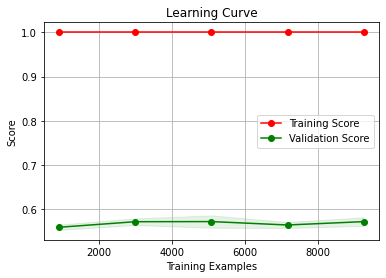

In [17]:
# 최적의 max_depth를 확인하려고 교차검증 대신 학습곡선을 이용했는데 두 그래프가 평행하게 나옴. 이는 과소적합 문제가 있다는 것을 나타내는데..잘 모르겠다. 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve

# 의사결정나무 모델 정의
dt = DecisionTreeClassifier(random_state=42)

# learning curve를 그리기 위한 함수 정의
def plot_learning_curve(estimator, X, y, ylim=None, cv=None, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    plt.figure()
    plt.title("Learning Curve")
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
    plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Validation Score")
    plt.legend(loc="best")
    plt.show()

# learning curve 그리기
plot_learning_curve(dt, X, y, cv=5)


 <h1>메타데이터 추출</h1>

In [3]:
import pandas as pd
import json
import os
from IPython.display import clear_output

sentiment_dir = 'C:/Users/dong_h02/Desktop/기계학습/petfinder-adoption-prediction/train_sentiment'
metadata_dir = 'C:/Users/dong_h02/Desktop/기계학습/petfinder-adoption-prediction/train_metadata'
image_dir = 'C:/Users/dong_h02/Desktop/기계학습/petfinder-adoption-prediction/train_images'

sentiment_word_cnt_list = []
sentiment_word_score_list = []
sentiment_valuable_word_cnt_list = []

df = pd.read_csv('C:/Users/dong_h02/Desktop/기계학습/petfinder-adoption-prediction/train/train.csv')

# sentiment
for i in range(df['PetID'].size):
    print(i, " Pet ID :", df['PetID'][i] , end = '')
    clear_output(wait = True)
    sentiment_json = sentiment_dir + "/" + df['PetID'][i] + '.json'
    if os.path.isfile(sentiment_json):
        with open(sentiment_json, encoding='UTF8') as f:
            data = json.load(f)
            total_cnt = 0
            total_score = 0
            for j in range(len(data['sentences'])):
                total_cnt = total_cnt + len(data['sentences'][j]['text']['content'].split())
                total_score = total_score + data['sentences'][j]['sentiment']['score']
            sentiment_word_cnt_list.append(total_cnt)
            sentiment_word_score_list.append(total_score)
            sentiment_valuable_word_cnt_list.append(len(data['entities']))
            #print("   Finish!!!")
    else:
        sentiment_word_cnt_list.append(-1)
        sentiment_word_score_list.append(-1)
        sentiment_valuable_word_cnt_list.append(-1)
        #print("   Fail!!!")
        
print("Finish!!!")
print("Finish!!!")
print("Finish!!!")
print("Finish!!!")
print("Finish!!!")

Finish!!!
Finish!!!
Finish!!!
Finish!!!
Finish!!!


In [4]:
import colorsys

metadata_object_cnt_list = []
metadata_object_h_list = []
metadata_object_s_list = []
metadata_object_v_list = []

# metadata
file_list = os.listdir(metadata_dir)
for i in range(df['PetID'].size):
    print(i, " Pet ID :", df['PetID'][i])
    clear_output(wait = True)
    duplicate_list = []
    total_cnt = 0
    total_h = 0
    total_s = 0
    total_v = 0
    hsv_cnt = 0
    for j in range(len(file_list)):
        if df['PetID'][i] in file_list[j]:
            duplicate_list.append(file_list[j])
    for j in range(len(duplicate_list)):
        metadata_json = metadata_dir + "/" + duplicate_list[j]
        try:
            with open(metadata_json, encoding='UTF8') as f:
                data = json.load(f)
                total_cnt = total_cnt + len(data['labelAnnotations'])
                for n in range(len(data['imagePropertiesAnnotation']['dominantColors']['colors'])):
                    color = data['imagePropertiesAnnotation']['dominantColors']['colors'][n]['color']
                    (r, g, b) = (color['red'] / 255, color['green'] / 255, color['blue'] / 255)
                    (h, s, v) = colorsys.rgb_to_hsv(r, g, b)
                    (h, s, v) = (int(h * 179), int(s * 255), int(v * 255))
                    total_h = total_h + h
                    total_s = total_s + s
                    total_v = total_v + v
                    hsv_cnt = hsv_cnt + 1
        except KeyError:
            continue
                
    metadata_object_cnt_list.append(total_cnt)
    if hsv_cnt == 0:
        metadata_object_h_list.append(-1)
        metadata_object_s_list.append(-1)
        metadata_object_v_list.append(-1)
    else:
        metadata_object_h_list.append(int(total_h / hsv_cnt))
        metadata_object_s_list.append(int(total_s / hsv_cnt))
        metadata_object_v_list.append(int(total_v / hsv_cnt))
print("Finish!!!")
print("Finish!!!")
print("Finish!!!")
print("Finish!!!")
print("Finish!!!")

Finish!!!
Finish!!!
Finish!!!
Finish!!!
Finish!!!


In [5]:
from PIL import Image

image_h_list = []
image_w_list = []

# image
file_list = os.listdir(image_dir)
for i in range(df['PetID'].size):
    print(i, " Pet ID :", df['PetID'][i])
    clear_output(wait = True)
    duplicate_list = []
    total_cnt = 0
    total_h = 0
    total_w = 0
    for j in range(len(file_list)):
        if df['PetID'][i] in file_list[j]:
            duplicate_list.append(file_list[j])
    for j in range(len(duplicate_list)):
        img_dir = image_dir + "/" + duplicate_list[j]
        im = Image.open(img_dir)
        width, height = im.size
        total_h += height
        total_w += width
        total_cnt += 1
        
    if total_cnt == 0:
        image_h_list.append(-1)
        image_w_list.append(-1)
    else:
        image_h_list.append(int(total_h / total_cnt))
        image_w_list.append(int(total_w / total_cnt))
print("Finish!!!")
print("Finish!!!")
print("Finish!!!")
print("Finish!!!")
print("Finish!!!")

Finish!!!
Finish!!!
Finish!!!
Finish!!!
Finish!!!


In [6]:
Metadata_df = pd.DataFrame({'PetID':df['PetID'],
                            'Description_SIZE':sentiment_word_cnt_list,
                            'Description_VALUABLE_SIZE':sentiment_valuable_word_cnt_list,
                            'Description_SCORE':sentiment_word_score_list,
                            'Object_SIZE':metadata_object_cnt_list,
                            'Object_COLOR_H':metadata_object_h_list,
                            'Object_COLOR_S':metadata_object_s_list,
                            'Object_COLOR_V':metadata_object_v_list,
                            'Image_WIDTH':image_w_list,
                            'Image_HEIGHT':image_h_list})
Metadata_df.to_csv("C:/Users/dong_h02/Desktop/기계학습/Metadata.csv")
Metadata_df

,PetID,Description_SIZE,Description_VALUABLE_SIZE,Description_SCORE,Object_SIZE,Object_COLOR_H,Object_COLOR_S,Object_COLOR_V,Image_WIDTH,Image_HEIGHT
0,86e1089a3,69,13,1.8,9,115,88,152,360,480
1,6296e909a,23,2,-0.5,17,38,98,94,349,388
2,3422e4906,69,13,1.4,68,18,68,135,357,342
3,5842f1ff5,25,6,0.9,77,15,75,142,375,325
4,850a43f90,81,13,3.5,29,38,86,155,516,444
...,...,...,...,...,...,...,...,...,...,...
14988,dc0935a84,78,7,2.4,30,35,43,108,360,480
14989,a01ab5b30,31,7,0.3,30,35,108,97,366,333
14990,d981b6395,9,2,2.5,48,40,56,105,360,480
14991,e4da1c9e4,18,4,0.9,30,36,103,83,356,366
